In [1]:
import pandas as pd
import seaborn as sns

#Cargamos el train
train = pd.read_csv('train_df.csv')

Los datos ya han sido importados y se ha comprobado que los únicos missing values correspondían a no estar en casa/en la habitación señalada, y han sido sustituidos por 0. Estudiamos la presencia de outliers.

In [2]:
train.sort_values('tiempo_redondeado', inplace=False)

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,tiempo_redondeado,Home,position
7931,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0,2019-11-06 11:37:00+01:00,0.0,not_home
2635,19.66,53.51,127.0,574.0,489.0,732.0,650.0,566.0,118.0,2019-11-06 11:42:00+01:00,1.0,Bathroom
4108,19.77,53.82,128.0,576.0,494.0,732.0,650.0,566.0,117.0,2019-11-06 11:43:00+01:00,1.0,Hallway
1147,19.66,53.82,128.0,578.0,496.0,732.0,650.0,566.0,116.0,2019-11-06 11:44:00+01:00,1.0,Living room
8055,19.60,53.87,128.0,579.0,496.0,732.0,650.0,565.0,114.0,2019-11-06 11:45:00+01:00,0.0,not_home
...,...,...,...,...,...,...,...,...,...,...,...,...
9950,20.66,58.33,44.0,518.0,520.0,692.0,633.0,579.0,173.0,2020-02-12 15:14:00+01:00,0.0,not_home
11323,20.69,58.25,44.0,517.0,520.0,693.0,635.0,580.0,173.0,2020-02-12 15:15:00+01:00,1.0,Living room
10139,20.69,57.54,45.0,517.0,525.0,698.0,641.0,587.0,172.0,2020-02-12 15:17:00+01:00,1.0,Bathroom
6595,20.58,56.70,43.0,518.0,530.0,702.0,646.0,595.0,170.0,2020-02-12 15:20:00+01:00,0.0,not_home


<Axes: xlabel='Home', ylabel='count'>

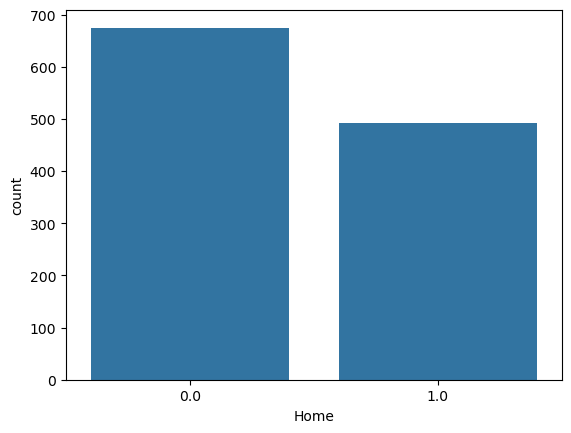

In [3]:

filtro_rango_1 = train['tiempo_redondeado'].between('2020-01-25', '2020-01-29')
filtro_rango_2 = train['tiempo_redondeado'] > '2020-01-29'

fechas_nadie = train[filtro_rango_1 | filtro_rango_2]

sns.countplot(data=fechas_nadie, x="Home")

Apreciamos que en el rango de tiempo en el que el individuo no está en casa la variable home no lo refleja correctamente.

<Axes: xlabel='position', ylabel='count'>

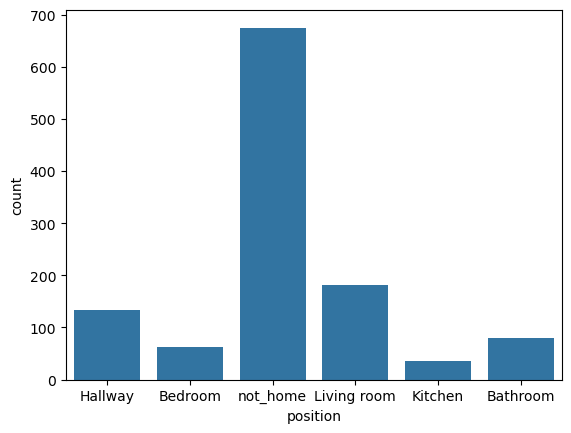

In [4]:
sns.countplot(data=fechas_nadie, x="position")


<Axes: xlabel='position', ylabel='count'>

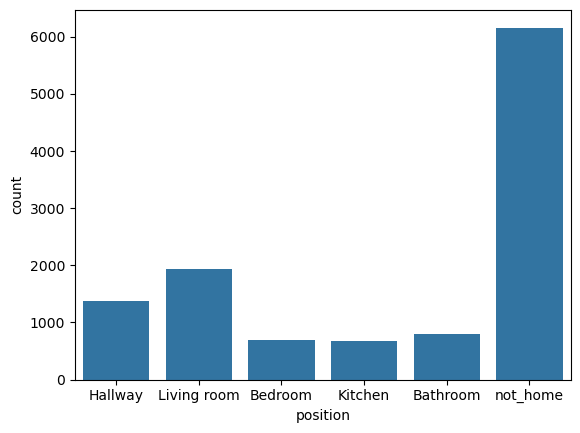

In [5]:
sns.countplot(data=train, x="position")

En las dos últimas gráficas apreciamos que no hay diferencias de comportamiento en los sensores de movimiento en los días que está el individuo y en los días que sabemos con certeza que está fuera.

Tareas:
- Corregir días en los que no hay nadie
- Valorar PCA
- Escalar los datos (comprobar normalidad para saber si usamos min_max o z_score)
- Trabajar con el ruido

<Axes: xlabel='Home', ylabel='count'>

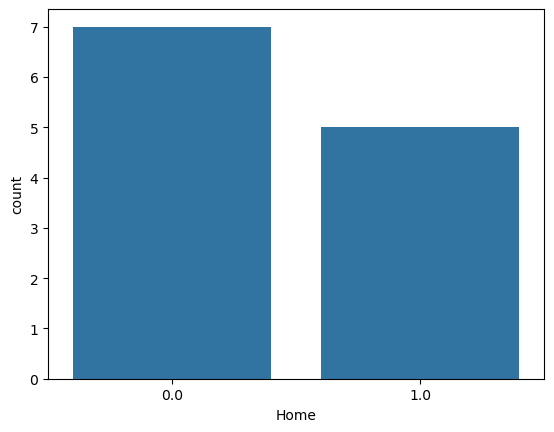

In [9]:
filtro_rango = train['tiempo_redondeado'].between('2020-01-27', '2020-02-02')
fechas_nadie_semana = train[filtro_rango]

sns.countplot(data=fechas_nadie_semana, x="Home")

In [ ]:
from sklearn.svm import LinearSVC  
from sklearn.model_selection import train_test_split
train_prueba, test_prueba = train_test_split(train, test_size=0.2, random_state=314159)
training_data = train_prueba.drop(columns=['Home', 'position', 'tiempo_redondeado'])
classes = train_prueba['Home']
test_data = test_prueba.drop(columns=['Home', 'position', 'tiempo_redondeado'])
class_test = test_prueba['Home']

svm = LinearSVC(random_state=314159, max_iter=2000, class_weight='balanced')
svm.fit(training_data, classes)

LinearSVC(class_weight='balanced', max_iter=2000, random_state=314159)

In [12]:
y_pred = svm.predict(test_data)
from sklearn.metrics import classification_report
print(classification_report(class_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.51      0.99      0.67      1184
         1.0       0.59      0.01      0.03      1143

    accuracy                           0.51      2327
   macro avg       0.55      0.50      0.35      2327
weighted avg       0.55      0.51      0.36      2327



In [14]:
from sklearn.svm import SVC
svm_rbf = SVC(random_state=314159)
svm_rbf.fit(training_data, classes)
y_pred_rbf = svm_rbf.predict(test_data)
print(classification_report(class_test, y_pred_rbf))


              precision    recall  f1-score   support

         0.0       0.51      1.00      0.67      1184
         1.0       0.00      0.00      0.00      1143

    accuracy                           0.51      2327
   macro avg       0.25      0.50      0.34      2327
weighted avg       0.26      0.51      0.34      2327



c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


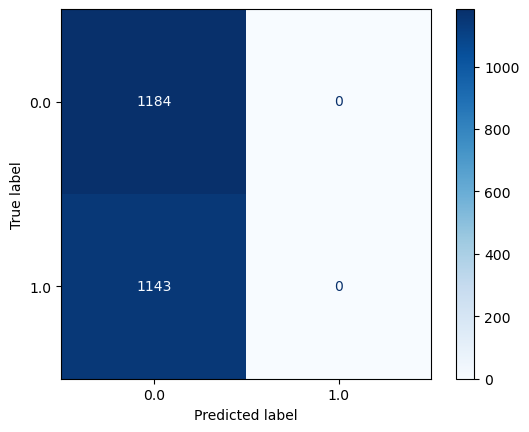

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_estimator(
        svm_rbf,
        test_data,
        class_test,
        cmap=plt.cm.Blues
    )

<Axes: xlabel='home', ylabel='count'>

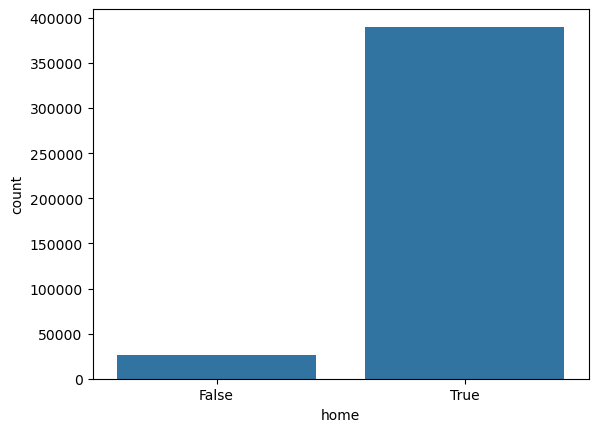

In [37]:
import numpy as np
data_gas = pd.read_csv('database_gas.csv')
filtro_rango = data_gas['timestamp'].between('2020-01-27', '2020-02-02')

data_gas["home"] = ~filtro_rango
sns.countplot(data=data_gas, x="home")


In [ ]:
train_prueba, test_prueba = train_test_split(data_gas, test_size=0.2, random_state=314159, shuffle=True, stratify=data_gas['home'])
training_data = train_prueba.drop(columns=['home', 'timestamp'])
classes = train_prueba['home']
test_data = test_prueba.drop(columns=['home', 'timestamp'])
class_test = test_prueba['home']

svm.fit(training_data, classes)
y_pred = svm.predict(test_data)

print(classification_report(class_test, y_pred)) 

              precision    recall  f1-score   support

       False       0.84      1.00      0.91      5184
        True       1.00      0.99      0.99     78047

    accuracy                           0.99     83231
   macro avg       0.92      0.99      0.95     83231
weighted avg       0.99      0.99      0.99     83231



In [40]:
train_prueba, test_prueba = train_test_split(train, test_size=0.2, random_state=314159)
training_data = train_prueba.drop(columns=['Home', 'position', 'tiempo_redondeado'])
classes = train_prueba['position']
test_data = test_prueba.drop(columns=['Home', 'position', 'tiempo_redondeado'])
class_test = test_prueba['position']

svm_position = LinearSVC(random_state=314159, max_iter=2000, class_weight='balanced')
svm_position.fit(training_data, classes)
y_pred_position = svm_position.predict(test_data)
print(classification_report(class_test, y_pred_position))

              precision    recall  f1-score   support

    Bathroom       0.00      0.00      0.00       171
     Bedroom       0.08      0.10      0.09       128
     Hallway       0.00      0.00      0.00       290
     Kitchen       0.10      0.04      0.05       140
 Living room       0.00      0.00      0.00       414
    not_home       0.50      0.90      0.65      1184

    accuracy                           0.47      2327
   macro avg       0.11      0.17      0.13      2327
weighted avg       0.27      0.47      0.34      2327



c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
# vamos a hacer knn para ver si mejora algo
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(training_data, classes)
y_pred_knn = knn.predict(test_data)
print(classification_report(class_test, y_pred_knn))

              precision    recall  f1-score   support

    Bathroom       0.06      0.05      0.05       171
     Bedroom       0.18      0.15      0.16       128
     Hallway       0.06      0.03      0.04       290
     Kitchen       0.05      0.01      0.02       140
 Living room       0.13      0.09      0.11       414
    not_home       0.45      0.60      0.51      1184

    accuracy                           0.34      2327
   macro avg       0.16      0.16      0.15      2327
weighted avg       0.28      0.34      0.30      2327



In [45]:
# No mejora nada, probamos con regresión logística
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(random_state=314159, max_iter=2000, class_weight='balanced')
logreg.fit(training_data, classes)
y_pred_logreg = logreg.predict(test_data)
print(classification_report(class_test, y_pred_logreg))

              precision    recall  f1-score   support

    Bathroom       0.08      0.17      0.11       171
     Bedroom       0.09      0.64      0.16       128
     Hallway       0.13      0.04      0.06       290
     Kitchen       0.08      0.47      0.14       140
 Living room       0.17      0.07      0.10       414
    not_home       0.61      0.02      0.03      1184

    accuracy                           0.10      2327
   macro avg       0.19      0.24      0.10      2327
weighted avg       0.37      0.10      0.07      2327



c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
# Cada vez peor, vamos a probar con Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(training_data, classes)
y_pred_gnb = gnb.predict(test_data)
print(classification_report(class_test, y_pred_gnb))


              precision    recall  f1-score   support

    Bathroom       0.00      0.00      0.00       171
     Bedroom       0.00      0.00      0.00       128
     Hallway       0.00      0.00      0.00       290
     Kitchen       0.00      0.00      0.00       140
 Living room       0.19      0.02      0.03       414
    not_home       0.51      0.98      0.67      1184

    accuracy                           0.50      2327
   macro avg       0.12      0.17      0.12      2327
weighted avg       0.29      0.50      0.35      2327



c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jorge\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
# Tristisimo. Vamos a probar con árboles de decisión.
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=314159, class_weight='balanced')
dtc.fit(training_data, classes)
y_pred_dtc = dtc.predict(test_data)
print(classification_report(class_test, y_pred_dtc))

              precision    recall  f1-score   support

    Bathroom       0.07      0.08      0.08       171
     Bedroom       0.16      0.16      0.16       128
     Hallway       0.06      0.06      0.06       290
     Kitchen       0.06      0.05      0.06       140
 Living room       0.09      0.09      0.09       414
    not_home       0.42      0.41      0.41      1184

    accuracy                           0.25      2327
   macro avg       0.14      0.14      0.14      2327
weighted avg       0.25      0.25      0.25      2327

